In [3]:
import shap
import optuna
from sklearn import set_config
from xgboost import XGBRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

## Dataset

In [4]:
set_config(transform_output="pandas")

In [5]:
# load the data

data = fetch_california_housing(as_frame=True)

In [6]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [7]:
# make X and y

X, y = data.data, data.target

In [8]:
# columns names

feature_names = data.feature_names

feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [9]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [11]:
X.shape

(20640, 8)

In [12]:
# split the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of Training data: ", X_train.shape)
print("Shape of Testing data: ", X_test.shape)

Shape of Training data:  (16512, 8)
Shape of Testing data:  (4128, 8)


## Model

In [13]:
# model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42,
                         n_jobs=-1, learning_rate=0.2, n_estimators=200,
                         reg_lambda=50, max_depth=7, gamma=0.05,
                         enable_categorical=False)

In [14]:
# fit the training data
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.05, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [15]:
# claculate the predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# calculate the RMSE and R2 score
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

Train RMSE: 0.2891, R2: 0.9375
Test RMSE: 0.4410, R2: 0.8516


### HP Tuning

In [16]:
# tune the model

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 100),
        'gamma': trial.suggest_float('gamma', 0, 2),
        "subsample": trial.suggest_float('subsample', 0.7, 1.0),
        "n_jobs": -1,
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    # set the model with the parameters
    model = XGBRegressor()

    model.set_params(**params)

    # fit the model
    model.fit(X_train, y_train)

    # predict the test data
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2

In [17]:
# create a study
study = optuna.create_study(direction='maximize')

study.optimize(func=objective, n_trials=50, show_progress_bar=True, n_jobs=-1)

[I 2026-08-01 05:48:33,653] A new study created in memory with name: no-name-4aae8814-5c13-4c96-82f3-62b29debc52f


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-01 05:48:34,594] Trial 0 finished with value: 0.8216349123116966 and parameters: {'learning_rate': 0.2979602148305187, 'n_estimators': 397, 'max_depth': 9, 'reg_lambda': 9.981623693475514, 'gamma': 1.0005955393682706, 'subsample': 0.8139248352509518}. Best is trial 0 with value: 0.8216349123116966.
[I 2026-08-01 05:48:35,322] Trial 2 finished with value: 0.8234393506016338 and parameters: {'learning_rate': 0.2233219734287292, 'n_estimators': 220, 'max_depth': 10, 'reg_lambda': 67.10945605626549, 'gamma': 1.1657466973173407, 'subsample': 0.9763617349720247}. Best is trial 2 with value: 0.8234393506016338.
[I 2026-08-01 05:48:35,853] Trial 1 finished with value: 0.8228294697042358 and parameters: {'learning_rate': 0.048329409899141404, 'n_estimators': 159, 'max_depth': 8, 'reg_lambda': 92.04900455843925, 'gamma': 0.28530996809300846, 'subsample': 0.8137962401139736}. Best is trial 2 with value: 0.8234393506016338.
[I 2026-08-01 05:48:36,182] Trial 4 finished with value: 0.8031

In [18]:
# get the best parameters
study.best_params

{'learning_rate': 0.1084418353061226,
 'n_estimators': 436,
 'max_depth': 7,
 'reg_lambda': 22.921997994526222,
 'gamma': 0.1223687553864112,
 'subsample': 0.8813241639976213}

In [19]:
# get the best value
study.best_value

0.8516892413752863

In [20]:
# get the best estimator
best_model = XGBRegressor(**study.best_params)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1223687553864112, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1084418353061226, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=436, n_jobs=None,
             num_parallel_tree=None, ...)

In [21]:
# print the metrics
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

Train RMSE: 0.2523, R2: 0.9524
Test RMSE: 0.4412, R2: 0.8514


## SHAP

In [22]:
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1223687553864112, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1084418353061226, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=436, n_jobs=None,
             num_parallel_tree=None, ...)

In [28]:
# create the tree explainer

explainer = shap.TreeExplainer(model=best_model,
                               data=X_train)

In [31]:
# Reduce background size to 500 (this will make it ~33x faster)
masker = shap.maskers.Independent(
    X_train,
    max_samples=500
)

explainer = shap.TreeExplainer(
    xgb_model,
    data=masker,
    feature_perturbation="interventional"
)
shap_values = explainer(X_test)

100%|===================| 4120/4128 [05:08<00:00]       

In [32]:
# expected value
explainer.expected_value

np.float64(2.086791726995355)

In [34]:
shap_values

.values =
array([[-0.43837288,  0.01181004, -0.16142038, ..., -0.20576177,
        -0.69792526, -0.07609401],
       [-0.39690032,  0.00711549, -0.11317826, ..., -0.02914475,
        -0.74691818,  0.00722433],
       [ 0.02456026,  0.42090482, -0.1071237 , ...,  0.80815817,
         0.18320243,  1.55283825],
       ...,
       [ 1.66616305, -0.01500889,  0.40520825, ...,  0.02698229,
        -0.04298683,  0.77860621],
       [-0.32319679, -0.03191517, -0.08313006, ..., -0.02997114,
        -0.95609074, -0.0359064 ],
       [-0.10784776, -0.02610442, -0.23562138, ..., -0.32797465,
         0.26280683,  0.05386021]])

.base_values =
array([2.08679173, 2.08679173, 2.08679173, ..., 2.08679173, 2.08679173,
       2.08679173])

.data =
array([[   1.6812    ,   25.        ,    4.19220056, ...,    3.87743733,
          36.06      , -119.01      ],
       [   2.5313    ,   30.        ,    5.03938356, ...,    2.67979452,
          35.14      , -119.46      ],
       [   3.4801    ,   52.        

In [35]:
shap_values.shape

(4128, 8)

In [36]:
len(feature_names)

8

In [37]:
feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [38]:
shap_values[0:5]

.values =
array([[-0.43837288,  0.01181004, -0.16142038,  0.00411246, -0.01910074,
        -0.20576177, -0.69792526, -0.07609401],
       [-0.39690032,  0.00711549, -0.11317826,  0.01309305,  0.01777202,
        -0.02914475, -0.74691818,  0.00722433],
       [ 0.02456026,  0.42090482, -0.1071237 ,  0.05466099,  0.01243829,
         0.80815817,  0.18320243,  1.55283825],
       [ 0.34519569,  0.02799439,  0.11473308, -0.00707392,  0.00581503,
        -0.29545949,  0.19469975,  0.04727376],
       [-0.16855495,  0.02241516, -0.01643573,  0.00279377, -0.01034619,
         0.02248048, -0.3589707 ,  0.81795981]])

.base_values =
array([2.08679173, 2.08679173, 2.08679173, 2.08679173, 2.08679173])

.data =
array([[ 1.68120000e+00,  2.50000000e+01,  4.19220056e+00,
         1.02228412e+00,  1.39200000e+03,  3.87743733e+00,
         3.60600000e+01, -1.19010000e+02],
       [ 2.53130000e+00,  3.00000000e+01,  5.03938356e+00,
         1.19349315e+00,  1.56500000e+03,  2.67979452e+00,
         3.5

In [39]:
X_test.head(1).values

array([[ 1.68120000e+00,  2.50000000e+01,  4.19220056e+00,
         1.02228412e+00,  1.39200000e+03,  3.87743733e+00,
         3.60600000e+01, -1.19010000e+02]])

### GLOBAL PLOTS

In [ ]:
shap_values

.values =
array([[-0.3953383 ,  0.01198073, -0.1423576 , ..., -0.22561105,
        -0.48343605, -0.24418639],
       [-0.43746433,  0.03760965, -0.11187227, ..., -0.06831243,
        -0.52572477, -0.17866977],
       [ 0.13043879,  0.43603915, -0.06949572, ...,  0.9120889 ,
         0.22314371,  1.5607861 ],
       ...,
       [ 1.8078415 ,  0.00233424,  0.20985016, ..., -0.01058364,
         0.04163118,  0.7171675 ],
       [-0.35178873, -0.03859442, -0.02291014, ..., -0.02056242,
        -0.7707404 , -0.14199683],
       [-0.04707546, -0.01269979, -0.28768644, ..., -0.29979604,
         0.25737575, -0.03681101]], dtype=float32)

.base_values =
array([2.0720177, 2.0720177, 2.0720177, ..., 2.0720177, 2.0720177,
       2.0720177], dtype=float32)

.data =
array([[   1.6812    ,   25.        ,    4.19220056, ...,    3.87743733,
          36.06      , -119.01      ],
       [   2.5313    ,   30.        ,    5.03938356, ...,    2.67979452,
          35.14      , -119.46      ],
       [   3

In [ ]:
shap_values.shape

(4128, 8)

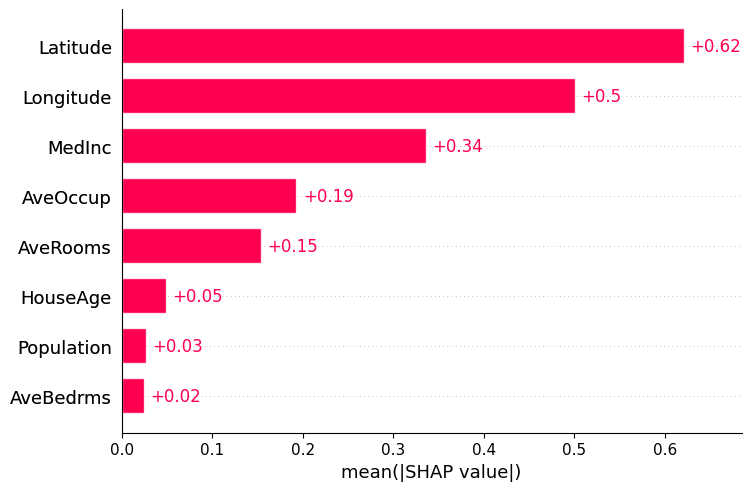

In [40]:
# bar plot to plot feature importance

shap.plots.bar(shap_values)

In [41]:
shap_values.abs.mean(axis=0)

.values =
array([0.33580854, 0.0491805 , 0.15382087, 0.02437972, 0.02657503,
       0.19275379, 0.62104295, 0.50081701])

.base_values =
np.float64(2.0867917269953553)

.data =
array([3.83033798e+00, 2.87642926e+01, 5.40405863e+00, 1.09663675e+00,
       1.42157171e+03, 2.96543102e+00, 3.55867103e+01, 1.19519360e+02])

In [42]:
shap_values.abs.mean(axis=0).values

array([0.33580854, 0.0491805 , 0.15382087, 0.02437972, 0.02657503,
       0.19275379, 0.62104295, 0.50081701])

In [43]:
dict(zip(feature_names,shap_values.abs.mean(axis=0).values))

{'MedInc': np.float64(0.33580854175752317),
 'HouseAge': np.float64(0.04918050003828261),
 'AveRooms': np.float64(0.1538208663190122),
 'AveBedrms': np.float64(0.024379722726862542),
 'Population': np.float64(0.0265750329088597),
 'AveOccup': np.float64(0.19275378798097087),
 'Latitude': np.float64(0.6210429541854933),
 'Longitude': np.float64(0.5008170110939777)}

In [44]:
feature_importances = {feature:shap_val.item() for feature, shap_val in
                    zip(feature_names,shap_values.abs.mean(axis=0).values)}

In [45]:
feature_importances

{'MedInc': 0.33580854175752317,
 'HouseAge': 0.04918050003828261,
 'AveRooms': 0.1538208663190122,
 'AveBedrms': 0.024379722726862542,
 'Population': 0.0265750329088597,
 'AveOccup': 0.19275378798097087,
 'Latitude': 0.6210429541854933,
 'Longitude': 0.5008170110939777}

In [46]:
sorted(feature_importances, key=feature_importances.get, reverse=True)

['Latitude',
 'Longitude',
 'MedInc',
 'AveOccup',
 'AveRooms',
 'HouseAge',
 'Population',
 'AveBedrms']

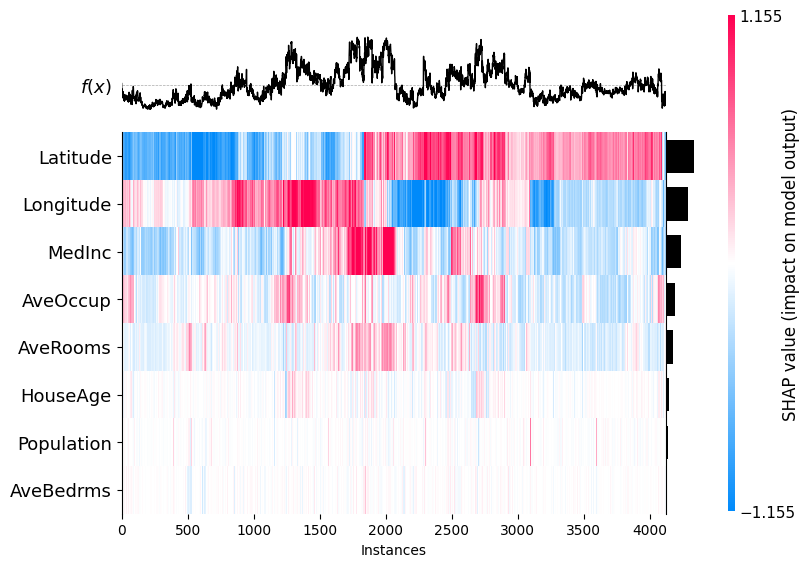

<Axes: xlabel='Instances'>

In [47]:
# heatmap plot

shap.plots.heatmap(shap_values)

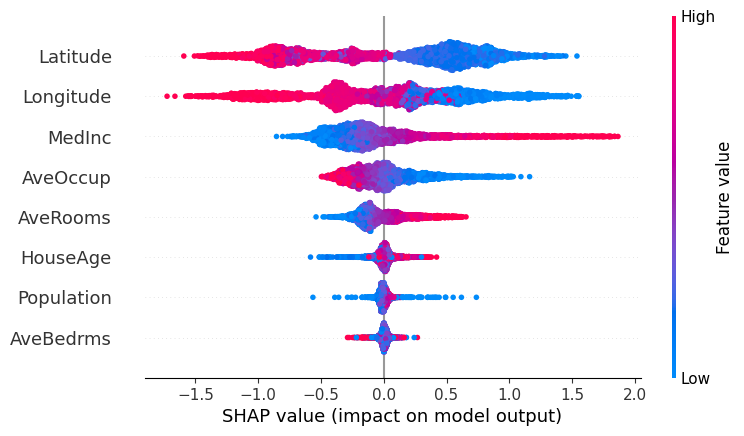

In [48]:
# summary plot

shap.plots.beeswarm(shap_values)

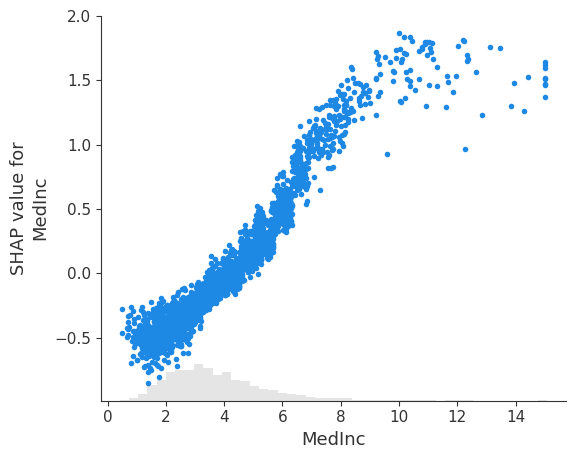

In [49]:
# scatter plot (Dependence Plot)
shap.plots.scatter(shap_values[:, "MedInc"])

In [50]:
shap_values[:, "Latitude"]

.values =
array([-0.69792526, -0.74691818,  0.18320243, ..., -0.04298683,
       -0.95609074,  0.26280683])

.base_values =
array([2.08679173, 2.08679173, 2.08679173, ..., 2.08679173, 2.08679173,
       2.08679173])

.data =
array([36.06, 35.14, 37.8 , ..., 37.31, 36.77, 34.22])

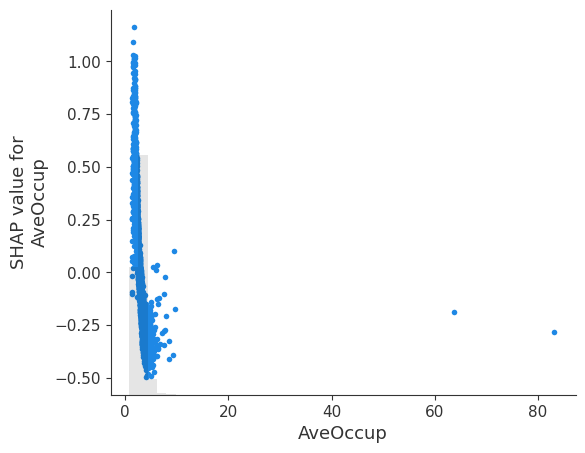

In [51]:
shap.plots.scatter(shap_values[:, "AveOccup"])

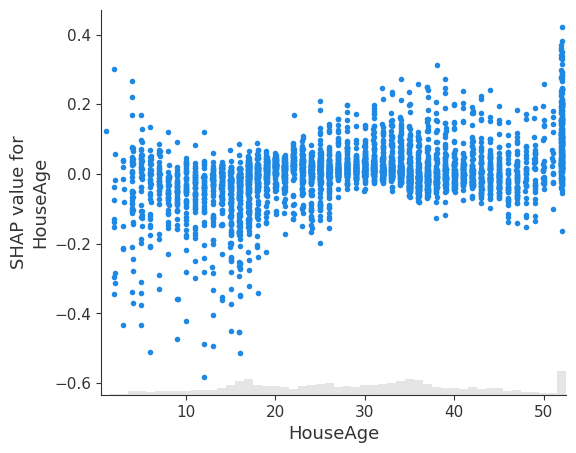

In [52]:
shap.plots.scatter(shap_values[:, "HouseAge"])

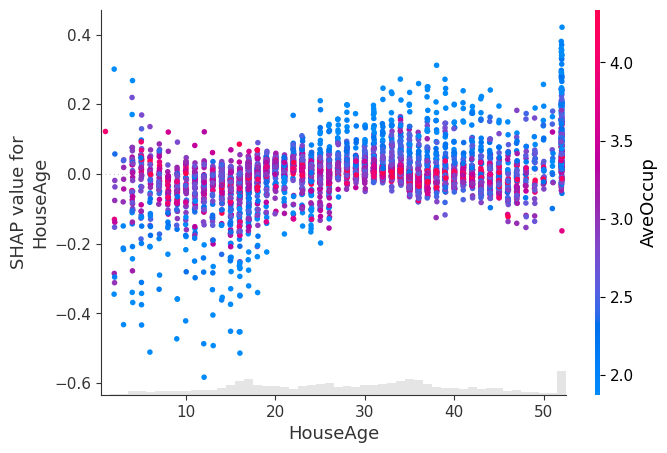

In [53]:
# scatter plot with interaction

shap.plots.scatter(shap_values[:, "HouseAge"], color=shap_values)

### LOCAL PLOTS

In [62]:
test_case = X_test.sample(1)

test_case

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
17383,4.5536,9.0,6.53494,1.031325,1116.0,2.689157,34.96,-120.41


In [63]:
explained_row = explainer(test_case)

explained_row

.values =
array([[ 0.04592558, -0.05305991,  0.21463187,  0.07665087,  0.00362666,
         0.01399807, -0.46623187,  0.14696135]])

.base_values =
array([2.08679173])

.data =
array([[ 4.55360000e+00,  9.00000000e+00,  6.53493976e+00,
         1.03132530e+00,  1.11600000e+03,  2.68915663e+00,
         3.49600000e+01, -1.20410000e+02]])

In [64]:
explained_row[0,:].shape

(8,)

In [65]:
explained_row.shape

(1, 8)

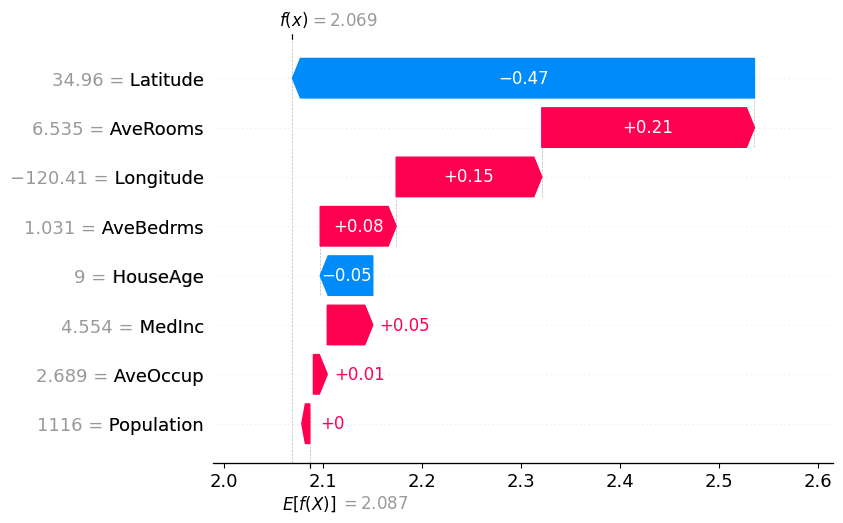

In [66]:
# waterfall plot

shap.plots.waterfall(explained_row[0])

In [67]:
# force plot

shap.plots.initjs()

shap.plots.force(explained_row[0])

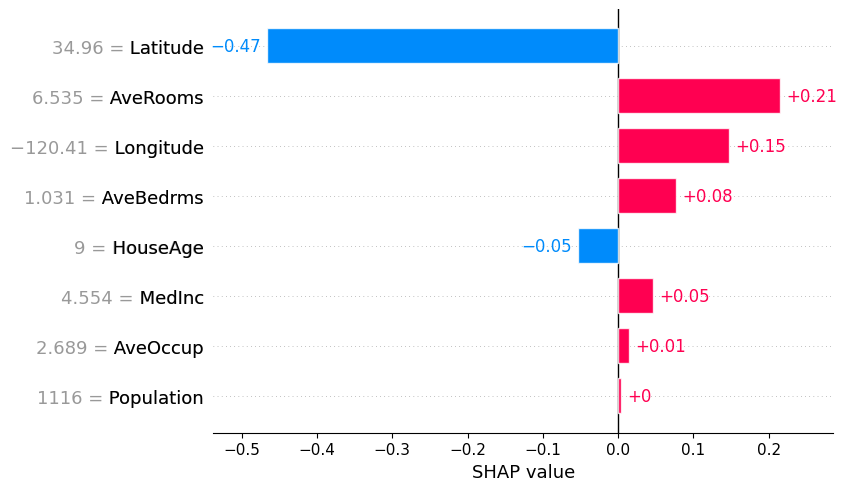

In [68]:
# bar plot for local explaination

shap.plots.bar(explained_row[0])

## LIME

In [69]:
# test case

test_case

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
17383,4.5536,9.0,6.53494,1.031325,1116.0,2.689157,34.96,-120.41


In [70]:
# convert test case to a 1D array

test_case_lime = test_case.values.flatten()

In [71]:
from lime.lime_tabular import LimeTabularExplainer

In [72]:
X_train.values.shape

(16512, 8)

In [73]:
# feature names

feature_names = X_train.columns.tolist()

In [74]:
# make an lime explainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    mode="regression",
    feature_names=feature_names
)

In [75]:
# get the lime explanations

lime_explanation = lime_explainer.explain_instance(
    data_row=test_case_lime,
    predict_fn=xgb_model.predict
)

In [76]:
# lime explanations --> list of values

lime_explanation.as_list()

[('34.26 < Latitude <= 37.72', -0.6113549250580768),
 ('AveRooms > 6.06', 0.4007718847640737),
 ('-121.81 < Longitude <= -118.51', 0.3808304900967263),
 ('2.43 < AveOccup <= 2.82', 0.1103031836529358),
 ('HouseAge <= 18.00', -0.10103882751127921),
 ('3.55 < MedInc <= 4.77', -0.09244709830626566),
 ('1.01 < AveBedrms <= 1.05', 0.042848750601322906),
 ('789.00 < Population <= 1167.00', 0.0024894591728254166)]

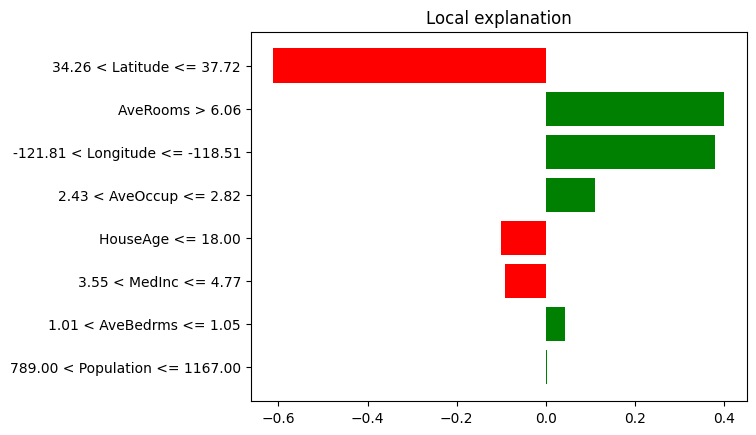

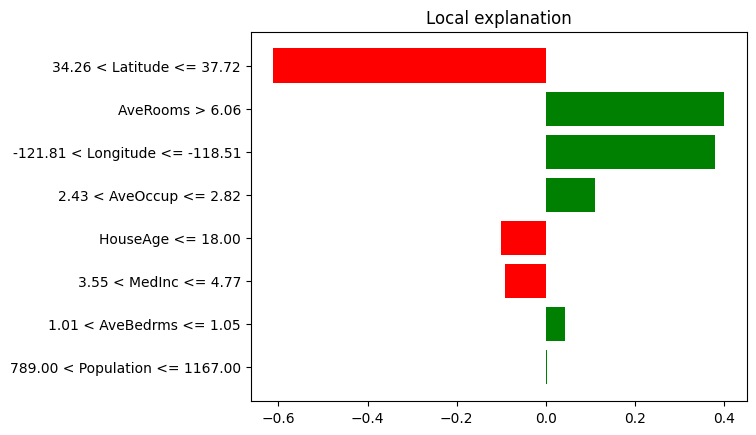

In [77]:
# lime explanations --> pyplot figure

lime_explanation.as_pyplot_figure()

In [78]:
# lime explanations --> as html

from IPython.core.display import HTML

In [79]:
xgb_model.predict(test_case)

array([2.0692937], dtype=float32)

In [80]:
# display explanation

display(HTML(lime_explanation.as_html()))